## 1. TẢI THƯ VIỆN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

## 2. THÔNG TIN VÀ MÔ TẢ BÀI TOÁN

In [ ]:
pd.set_option('display.max_columns', 500)
plt.style.use('seaborn-v0_8-darkgrid')

print("=" * 70)
print("ĐỒ ÁN: DỰ ĐOÁN PHÍ BẢO HIỂM")

print("=" * 70)

ĐỒ ÁN: DỰ ĐOÁN PHÍ BẢO HIỂM


## 3. LOAD DỮ LIỆU

In [ ]:
# Đọc dữ liệu từ Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Đọc file train
train = pd.read_csv("/content/drive/MyDrive/Insurance/train.csv")
print(f"Train shape: {train.shape}")

Train shape: (1200000, 21)


In [ ]:
# Hiển thị 5 dòng đầu
print("\n Xem trước dữ liệu:")
train.head()


 Xem trước dữ liệu:


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,40.0,Male,41731.97,Married,NaN,Master's,Employed,75.453231,Urban,Basic,1.0,20.0,569.3,2.0,2022-04-30 15:31:56.225583,Average,Yes,Weekly,House,1747.52
1,1,31.0,Female,44641.07,Single,2.0,PhD,Self-Employed,82.341129,Urban,Premium,1.0,6.0,636.7,6.0,2021-09-21 11:37:11.207480,Average,No,Monthly,House,3028.71
2,2,30.0,Male,8055.38,Married,4.0,PhD,Self-Employed,85.681292,Suburban,Premium,0.0,5.0,486.6,2.0,2022-07-07 04:39:46.240354,Good,No,Weekly,House,2486.44
3,3,30.0,Male,68837.36,Divorced,4.0,Bachelor's,Unemployed,66.243119,Suburban,Comprehensive,1.0,1.0,721.3,8.0,2020-10-04 06:24:00.326234,Good,No,Daily,Apartment,2301.70
4,4,58.0,Male,39087.47,Married,1.0,High School,Employed,63.077002,Urban,Premium,3.0,10.0,524.9,9.0,2022-04-07 00:13:05.851454,Poor,No,Weekly,House,3295.40


In [ ]:
# Đọc file test
test = pd.read_csv("/content/drive/MyDrive/Insurance/test.csv")
print(f"Test shape: {test.shape}")

Test shape: (800000, 20)


In [ ]:
# Hiển thị 5 dòng đầu
print("\n Xem trước dữ liệu:")
test.head()


 Xem trước dữ liệu:


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,1200000,28.0,Female,2310.0,NaN,4.0,Bachelor's,Self-Employed,7.657981,Rural,Basic,NaN,19.0,NaN,1.0,2023-06-04 15:21:39.245086,Poor,Yes,Weekly,House
1,1200001,31.0,Female,126031.0,Married,2.0,Master's,Self-Employed,13.381379,Suburban,Premium,NaN,14.0,372.0,8.0,2024-04-22 15:21:39.224915,Good,Yes,Rarely,Apartment
2,1200002,47.0,Female,17092.0,Divorced,0.0,PhD,Unemployed,24.354527,Urban,Comprehensive,NaN,16.0,819.0,9.0,2023-04-05 15:21:39.134960,Average,Yes,Monthly,Condo
3,1200003,28.0,Female,30424.0,Divorced,3.0,PhD,Self-Employed,5.136225,Suburban,Comprehensive,1.0,3.0,770.0,5.0,2023-10-25 15:21:39.134960,Poor,Yes,Daily,House
4,1200004,24.0,Male,10863.0,Divorced,2.0,High School,Unemployed,11.844155,Suburban,Premium,NaN,14.0,755.0,7.0,2021-11-26 15:21:39.259788,Average,No,Weekly,House


### 3. EDA - KHÁM PHÁ DỮ LIỆU

In [ ]:
# 3.1. Thông tin tổng quan
print("\n 3.1. THÔNG TIN TỔNG QUAN")
print("-" * 70)
print(f"Số dòng: {train.shape[0]:,}")
print(f"Số cột: {train.shape[1]}")
print(f"\n Các cột trong dữ liệu:")
print(train.columns.tolist())


 3.1. THÔNG TIN TỔNG QUAN
----------------------------------------------------------------------
Số dòng: 1,200,000
Số cột: 21

 Các cột trong dữ liệu:
['id', 'Age', 'Gender', 'Annual Income', 'Marital Status', 'Number of Dependents', 'Education Level', 'Occupation', 'Health Score', 'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Policy Start Date', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type', 'Premium Amount']


### Kiểm tra dữ liệu bị thiếu

In [ ]:
# 3.2. Kiểm tra Missing Values
missing = train.isnull().sum()
missing_pct = 100 * missing / len(train)
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df.to_string(index=False))


 3.2. KIỂM TRA MISSING VALUES
----------------------------------------------------------------------
              Column  Missing Count  Missing %
        Credit Score         120000       10.0
     Previous Claims          96000        8.0
Number of Dependents          84000        7.0
          Occupation          60000        5.0
        Health Score          60000        5.0
   Customer Feedback          48000        4.0
       Annual Income          36000        3.0
                 Age          12000        1.0
         Vehicle Age           6000        0.5
  Insurance Duration           2400        0.2


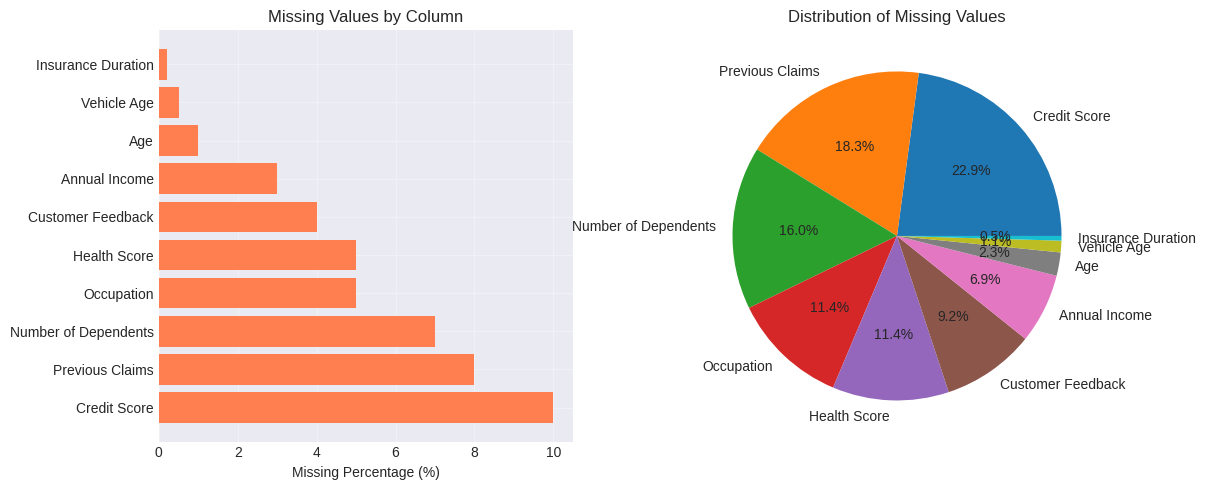

In [ ]:
# Visualization Missing Values
if len(missing_df) > 0:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.barh(missing_df['Column'], missing_df['Missing %'], color='coral')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.pie(missing_df['Missing Count'], labels=missing_df['Column'], autopct='%1.1f%%')
    plt.title('Distribution of Missing Values')
    plt.tight_layout()
    plt.show()

### Thống kê mô tả - biến số

In [ ]:
train.describe().T


🔍 3.3. THỐNG KÊ MÔ TẢ - BIẾN SỐ
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
id,1200000.0,599999.500000,346410.305852,0.0,299999.750000,599999.500000,899999.250000,1199999.0
Age,1188000.0,34.755160,12.713238,18.0,25.000000,33.000000,42.000000,80.0
Annual Income,1164000.0,45029.873048,25923.588976,8000.0,25903.432500,40099.515000,58800.025000,250000.0
Number of Dependents,1116000.0,1.869827,1.236798,0.0,1.000000,2.000000,3.000000,5.0
Health Score,1140000.0,74.702131,14.380705,5.0,64.864222,74.997408,85.119519,100.0
Previous Claims,1104000.0,1.199011,1.089395,0.0,0.000000,1.000000,2.000000,5.0
Vehicle Age,1194000.0,9.999693,6.053326,0.0,5.000000,10.000000,15.000000,20.0
Credit Score,1080000.0,649.547181,88.945282,300.0,589.300000,650.000000,710.700000,850.0
Insurance Duration,1197600.0,5.502177,2.871980,1.0,3.000000,6.000000,8.000000,10.0
Premium Amount,1200000.0,2360.651251,956.498390,500.0,1660.110000,2191.990000,2878.930000,5500.0


###Kiểm tra phân phối biến target

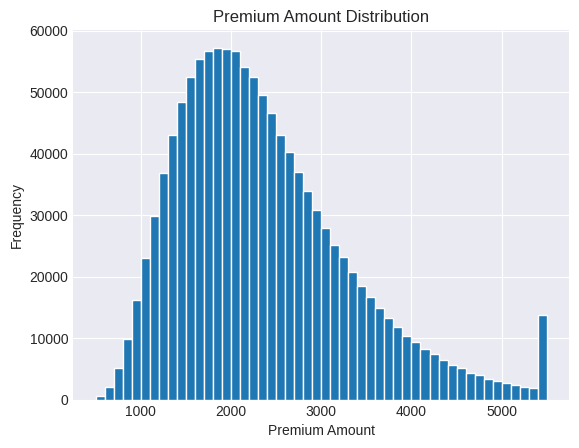

In [ ]:
plt.hist(
    train['Premium Amount'],
    bins=50,
    edgecolor='white',
    rwidth=1
)
plt.title('Premium Amount Distribution')
plt.xlabel('Premium Amount')
plt.ylabel('Frequency')
plt.show()


Nhận xét: Về biến này có dấu hiệu hơi lệch phải nhưng nhìn chung vẫn khá đồng đều

### Check ngoại lai của biến target

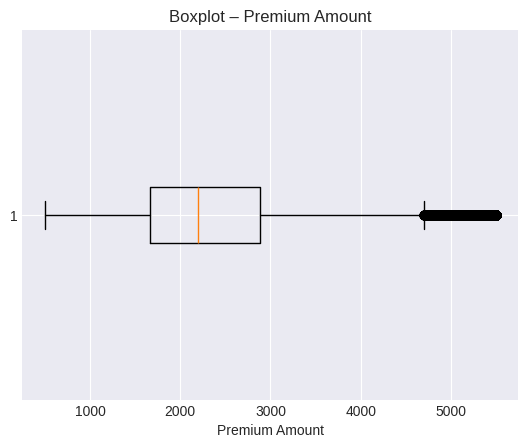

In [ ]:
plt.boxplot(train['Premium Amount'], vert=False)
plt.title('Boxplot – Premium Amount')
plt.xlabel('Premium Amount')
plt.show()

In [ ]:
Q1 = train['Premium Amount'].quantile(0.25)
Q3 = train['Premium Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train[
    (train['Premium Amount'] < lower_bound) |
    (train['Premium Amount'] > upper_bound)
]

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)}")


Lower bound: -168.12000000000012
Upper bound: 4707.16
Number of outliers: 32784


Nhận xét: \
Nhìn tổng quan boxplot cho thấy **Premium Amount** có phân phối lệch phải với nhiều giá trị lớn, tuy nhiên các outlier này không xuất hiện rời rạc mà hình thành một đuôi phân phối rõ ràng, phản ánh đặc thù của dữ liệu chứ không phải nhiễu ngẫu nhiên. Phần lớn quan sát vẫn tập trung trong khoảng giá trị trung tâm, giúp mô hình nắm bắt tốt xu hướng chính của dữ liệu. Do đó, dù hình ảnh outlier khá nhiều,**chúng không làm méo cấu trúc dữ liệu**, và hiệu quả dự báo tổng thể của mô hình vẫn được duy trì ở mức tốt.

### Kiểm tra phân phối của các biến phân loại


 3.5. PHÂN TÍCH BIẾN PHÂN LOẠI
----------------------------------------------------------------------
Số lượng biến phân loại: 10


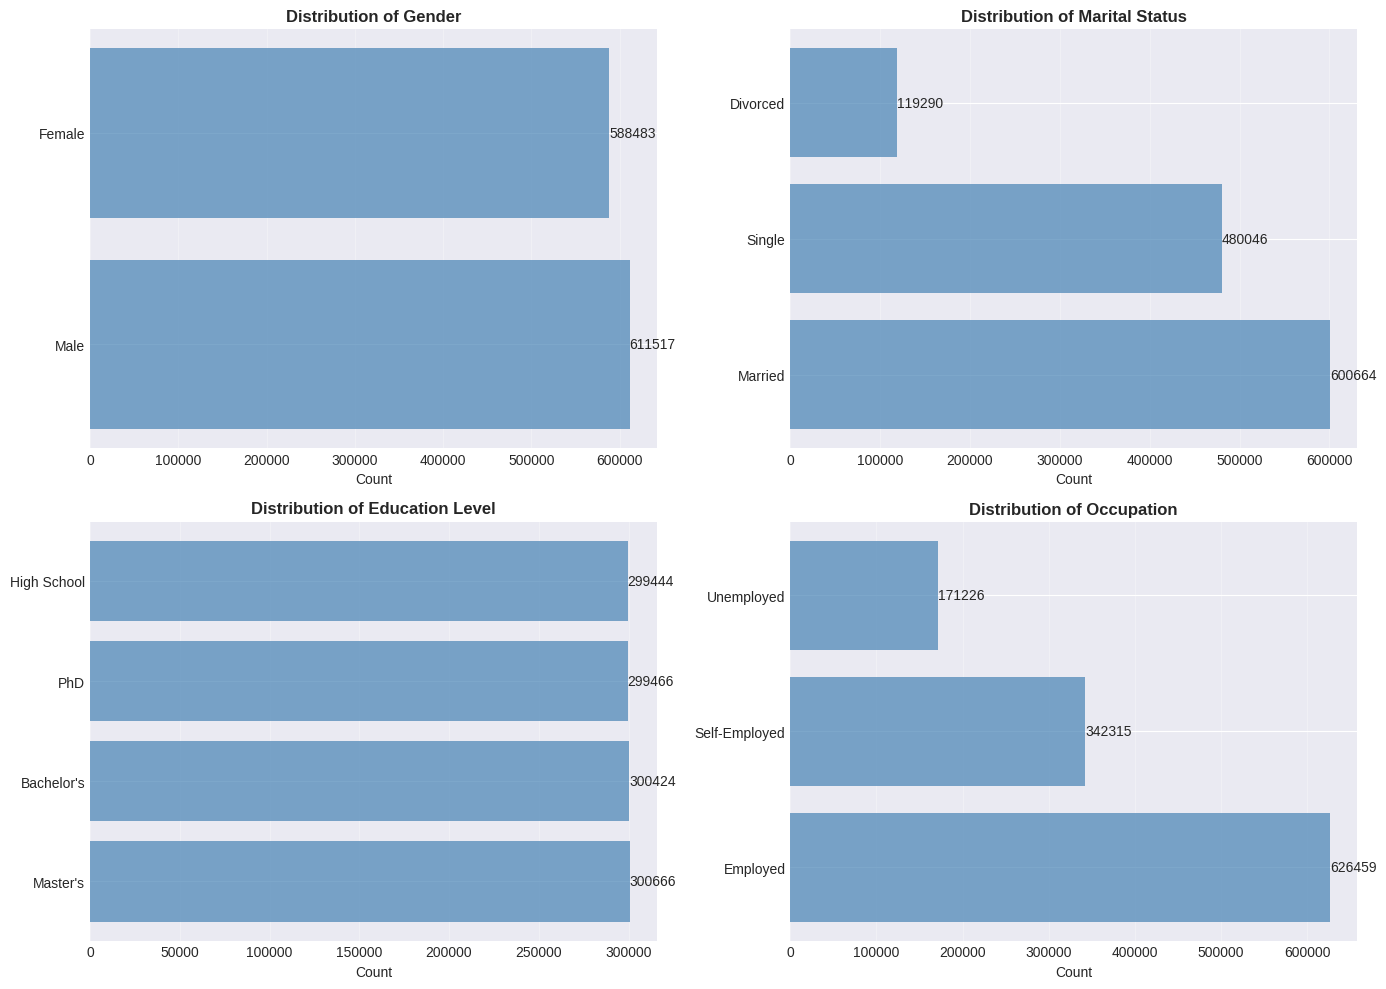

In [ ]:
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
if 'Policy Start Date' in categorical_cols:
    categorical_cols.remove('Policy Start Date')

# Visualization
if len(categorical_cols) >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for i, col in enumerate(categorical_cols[:4]):
        value_counts = train[col].value_counts().head(10)

        bars = axes[i].barh(
            range(len(value_counts)),
            value_counts.values,
            color='steelblue',
            alpha=0.7
        )

        axes[i].set_yticks(range(len(value_counts)))
        axes[i].set_yticklabels(value_counts.index)
        axes[i].set_xlabel('Count')
        axes[i].set_title(f'Distribution of {col}', fontweight='bold')
        axes[i].grid(True, alpha=0.3, axis='x')

        # ✅ THÊM LABEL SỐ LƯỢNG
        for bar in bars:
            width = bar.get_width()
            axes[i].text(
                width,
                bar.get_y() + bar.get_height() / 2,
                f'{int(width)}',
                va='center',
                ha='left',
                fontsize=10
            )

    plt.tight_layout()
    plt.show()


Nhận xét:
* Nhìn tổng thể, các biến nhân khẩu học trong tập dữ liệu có phân bố khá cân đối và đa dạng: giới tính nam và nữ gần như tương đương về số lượng, giúp hạn chế thiên lệch giới trong mô hình
* Tình trạng hôn nhân tập trung chủ yếu ở nhóm đã kết hôn và độc thân, trong khi nhóm ly hôn chiếm tỷ trọng nhỏ hơn nhưng vẫn đủ ý nghĩa phân tích
* Trình độ học vấn phân bổ tương đối đồng đều giữa các cấp, cho thấy mẫu dữ liệu bao phủ tốt nhiều tầng lớp tri thức
* Về nghề nghiệp, nhóm đang đi làm chiếm ưu thế rõ rệt, phản ánh đúng thực tế kinh tế, đồng thời vẫn tồn tại các nhóm tự kinh doanh và thất nghiệp để mô hình học được sự khác biệt về hành vi và mức phí bảo hiểm.

###Phân tích độ tương quan bằng heatmap


 3.6. PHÂN TÍCH TƯƠNG QUAN
----------------------------------------------------------------------

 Top 10 features tương quan cao nhất với Premium Amount:
Premium Amount          1.000000
Previous Claims         0.419890
Number of Dependents    0.207970
Annual Income           0.120295
Credit Score           -0.149424
Age                    -0.152978
Insurance Duration     -0.155846
Vehicle Age            -0.161726
Health Score           -0.258857


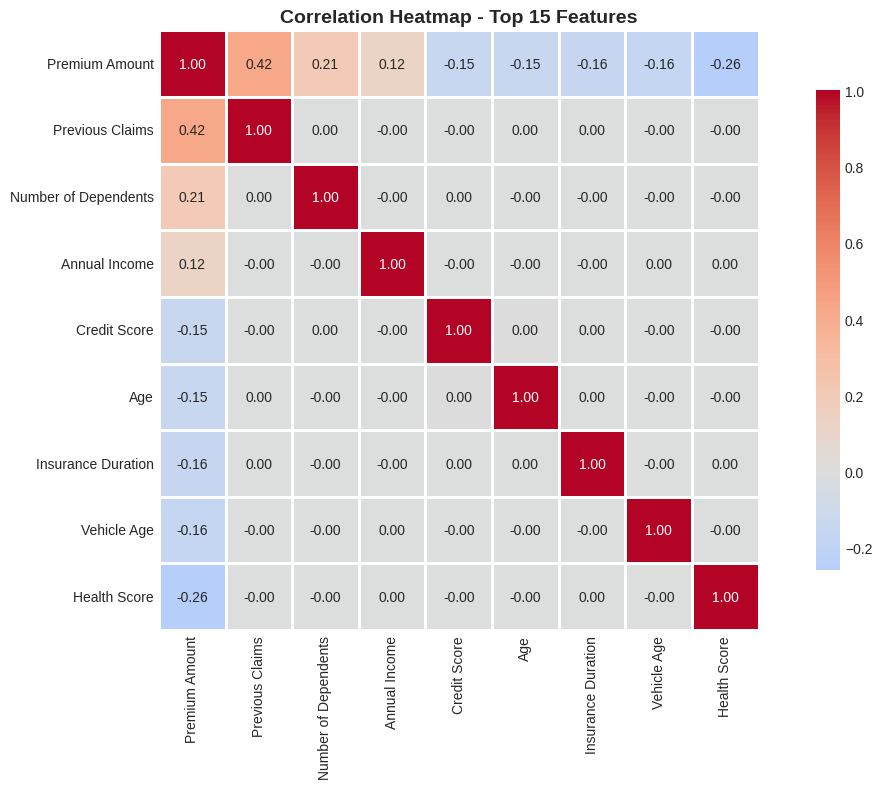

In [ ]:
# Chọn các biến số để kiểm tra độ tương quan
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in numeric_cols:
    numeric_cols.remove('id')

# Tính độ tương quan so với biến target
correlations = train[numeric_cols].corr()['Premium Amount'].sort_values(ascending=False)
print("\n Top 10 features tương quan cao nhất với Premium Amount:")
print(correlations.head(10).to_string())

# Visualize heatmap về độ tương quan
plt.figure(figsize=(12, 8))
top_features = correlations.head(15).index
corr_matrix = train[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Top 15 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Nhìn vào ma trận tương quan có thể thấy:
-  Premium Amount không phụ thuộc quá mạnh vào một biến đơn lẻ, mà chịu tác động tổng hợp của nhiều yếu tố (dựa vào quy tắc định phí phi tuyến hoặc tổ hợp nhiều yếu tố nghĩa là **Premium Amount không tăng/giảm đều theo từng biến riêng lẻ**, mà được tính dựa trên nhiều điều kiện kết hợp cùng lúc và theo các ngưỡng, mức, hoặc bảng quy tắc có sẵn).

-  Trong đó, Previous Claims có tương quan dương cao nhất, phản ánh việc khách hàng có lịch sử bồi thường nhiều thường phải trả phí cao hơn; Number of Dependents và Annual Income cũng có tương quan dương nhưng ở mức vừa phải, cho thấy quy mô gia đình và khả năng chi trả có ảnh hưởng nhất định đến mức phí.

- Ngược lại, các biến như Health Score, Vehicle Age, Insurance Duration, Age và Credit Score có tương quan âm, hàm ý rằng khách hàng có sức khỏe tốt hơn, xe cũ hơn, thời gian tham gia dài hơn hoặc hồ sơ tín dụng tốt thường được hưởng mức phí thấp hơn. \
==> Tổng thể, các hệ số tương quan ở mức thấp–trung bình cho thấy mối quan hệ mang tính phi tuyến và kết hợp, phù hợp với việc sử dụng các mô hình học máy để khai thác hiệu quả hơn so với các mô hình tuyến tính đơn giản.

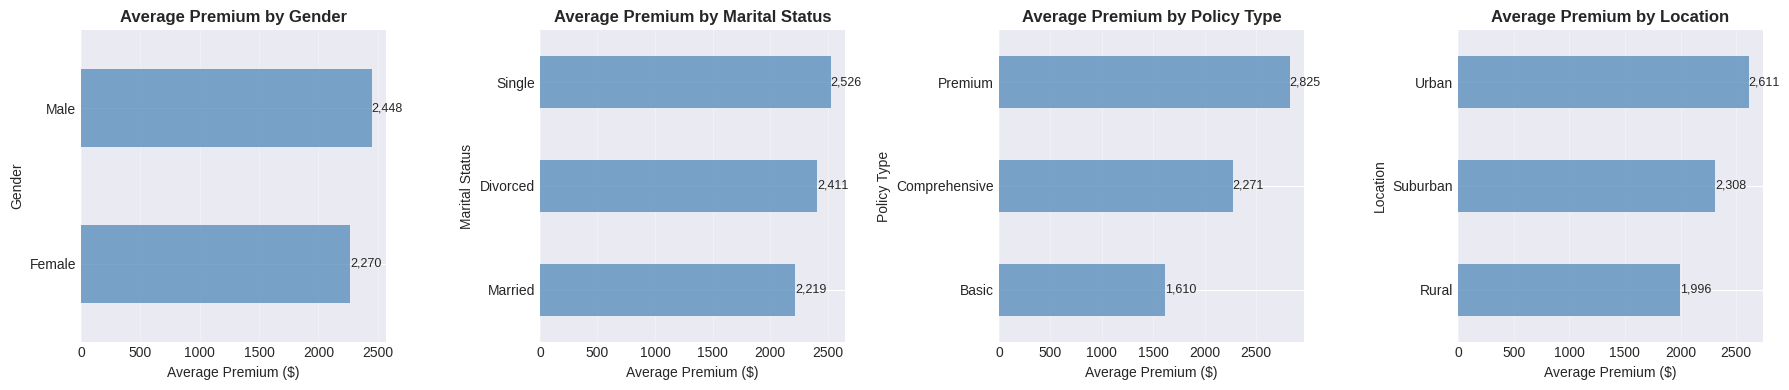

In [ ]:
# 3.7. Premium Amount theo các biến phân loại
key_categorical = ['Gender', 'Marital Status', 'Policy Type', 'Location']
existing_cats = [col for col in key_categorical if col in train.columns]

if len(existing_cats) >= 2:
    fig, axes = plt.subplots(1, len(existing_cats), figsize=(18, 4))
    if len(existing_cats) == 1:
        axes = [axes]

    for idx, col in enumerate(existing_cats):
        mean_values = train.groupby(col)['Premium Amount'].mean().sort_values()

        bars = mean_values.plot(
            kind='barh',
            ax=axes[idx],
            color='steelblue',
            alpha=0.7
        )

        axes[idx].set_title(f'Average Premium by {col}', fontweight='bold')
        axes[idx].set_xlabel('Average Premium ($)')
        axes[idx].grid(True, alpha=0.3, axis='x')

        # Thêm label cho chart
        for bar in axes[idx].patches:
            width = bar.get_width()
            axes[idx].text(
                width,
                bar.get_y() + bar.get_height() / 2,
                f'{width:,.0f}',
                va='center',
                ha='left',
                fontsize=9
            )

    plt.tight_layout()
    plt.show()


**Nhận xét**: Nhìn chung, average premium có sự khác biệt rõ theo từng nhóm: nam có mức phí trung bình cao hơn nữ; nhóm độc thân trả phí cao hơn so với đã kết hôn và ly hôn; theo loại hợp đồng, gói Premium có mức phí cao nhất, tiếp đến là Comprehensive và thấp nhất là Basic; còn theo khu vực, khách hàng ở đô thị có premium trung bình cao hơn ngoại ô và nông thôn, phản ánh mức độ rủi ro và khả năng chi trả khác nhau giữa các nhóm.


3.8. PHÂN TÍCH THEO TUỔI
----------------------------------------------------------------------


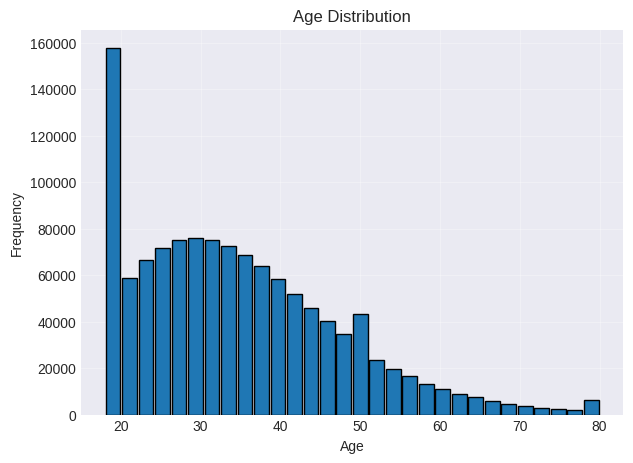

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(
    train['Age'],
    bins=30,
    edgecolor='black',
    rwidth=0.9
)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()


Nhận xét: Phân phối độ tuổi tập trung chủ yếu ở nhóm 20–40 tuổi, với đỉnh rơi vào khoảng cuối 20 đến đầu 30, sau đó giảm dần khi tuổi tăng. Phân phối lệch phải, cho thấy số lượng khách hàng lớn tuổi ít hơn nhưng vẫn hiện diện, phản ánh tập dữ liệu bao phủ tốt nhóm khách hàng chính trong độ tuổi lao động.

## 4. XỬ LÝ VÀ LÀM SẠCH DỮ LIỆU

### Tạo các biến thời gian

In [ ]:
def create_time_features(df):
    """Tạo các biến thời gian từ Policy Start Date"""
    df["Policy Start Date"] = pd.to_datetime(df["Policy Start Date"])
    df["year"] = df["Policy Start Date"].dt.year.astype("float32")
    df["month"] = df["Policy Start Date"].dt.month.astype("float32")
    df["day"] = df["Policy Start Date"].dt.day.astype("float32")
    df["dow"] = df["Policy Start Date"].dt.dayofweek.astype("float32")
    df["seconds"] = (df["Policy Start Date"].astype("int64") // 10**9).astype("float32")
    return df

train = create_time_features(train)
test = create_time_features(test)
print(f"Đã tạo 5 biến thời gian: year, month, day, dow, seconds")

Đã tạo 5 biến thời gian: year, month, day, dow, seconds


### Visualize các biến theo thời gian

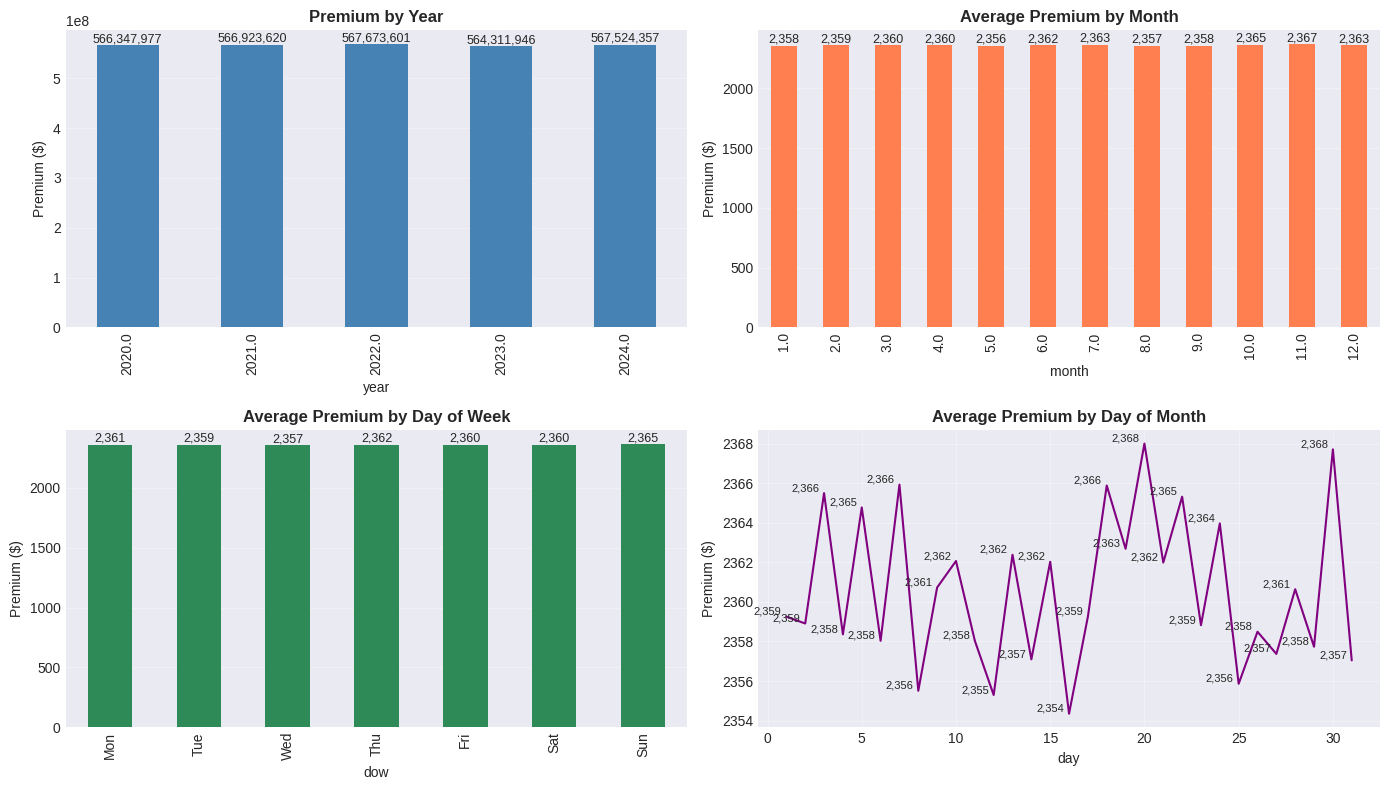

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ===== Year =====
year_mean = train.groupby('year')['Premium Amount'].sum()
bars = year_mean.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Premium by Year', fontweight='bold')
axes[0, 0].set_ylabel('Premium ($)')
axes[0, 0].grid(True, alpha=0.3)

for bar in axes[0, 0].patches:
    height = bar.get_height()
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# ===== Month =====
month_mean = train.groupby('month')['Premium Amount'].mean()
month_mean.plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Average Premium by Month', fontweight='bold')
axes[0, 1].set_ylabel('Premium ($)')
axes[0, 1].grid(True, alpha=0.3)

for bar in axes[0, 1].patches:
    height = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# ===== Day of Week =====
dow_mean = train.groupby('dow')['Premium Amount'].mean()
dow_mean.plot(kind='bar', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Average Premium by Day of Week', fontweight='bold')
axes[1, 0].set_ylabel('Premium ($)')
axes[1, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1, 0].grid(True, alpha=0.3)

for bar in axes[1, 0].patches:
    height = bar.get_height()
    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# ===== Day of Month =====
day_mean = train.groupby('day')['Premium Amount'].mean()
day_mean.plot(ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Average Premium by Day of Month', fontweight='bold')
axes[1, 1].set_ylabel('Premium ($)')
axes[1, 1].grid(True, alpha=0.3)

for x, y in enumerate(day_mean.values):
    axes[1, 1].text(
        x,
        y,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()


Nhận xét:\
Nhìn chung, premium khá ổn định theo thời gian: tổng premium theo năm chỉ dao động nhẹ, không có xu hướng tăng giảm rõ rệt; premium trung bình theo tháng và thứ trong tuần gần như đồng đều; còn theo ngày trong tháng chỉ biến động nhỏ quanh một mức trung bình, cho thấy yếu tố thời gian không ảnh hưởng mạnh đến mức phí bảo hiểm.

###Xác định các biến phân loại và biến số

In [ ]:
target = "Premium Amount"
remove_cols = ["id", "Policy Start Date", target]
features = [c for c in train.columns if c not in remove_cols]

# Phân loại features
categorical = [c for c in features if train[c].dtype == "object"]
numerical = [
    c for c in features
    if train[c].dtype in ["int64", "float64", "float32"]
]

print("Categorical:", categorical)
print("Numerical:", numerical)


Categorical: ['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type']
Numerical: ['Age', 'Annual Income', 'Number of Dependents', 'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'year', 'month', 'day', 'dow', 'seconds']


###  Fill nan cho cột số

In [ ]:
for col in numerical:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col]  = test[col].fillna(median_val)

print("Done fill NaN numerical columns")


Done fill NaN numerical columns


###Tách biến mục tiêu (target) và biến đầu vào (features)

In [ ]:
y = train[target].copy()
X_train = train.drop(columns=[target])
X_test = test.copy()

### Chia tập dữ liệu

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y,
    test_size=0.2,
    random_state=42
)

Gộp train + val + test của file train để xử lý feature (KHÔNG leak)

In [ ]:
# Kết hợp để xử lý consistent
combined = pd.concat([X_tr, X_val, X_test], axis=0, ignore_index=True)

### Mã hóa và xử lý dữ liệu object (biến phân loại) và biến numerical

In [ ]:
for col in categorical:
    combined[col] = combined[col].fillna("unknown")
    combined[col], _ = combined[col].factorize()
    combined[col] -= combined[col].min()  # đảm bảo bắt đầu từ 0

In [ ]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# tính median CHỈ trên train
num_fill_map = {
    col: X_train[col].median()
    for col in numeric_cols
}

# fill cho train
for col, val in num_fill_map.items():
    X_train[col] = X_train[col].fillna(val)

# fill cho test (dùng cùng median)
for col, val in num_fill_map.items():
    X_test[col] = X_test[col].fillna(val)


Filled NaN for numeric columns in combined


### Sau khi xử lý xong, tách ra để chạy model về sau

In [ ]:
# Tách lại
X_tr = combined.iloc[:len(X_tr)].copy()
X_val = combined.iloc[len(X_tr):len(X_tr)+len(X_val)].copy()
X_test = combined.iloc[len(X_tr)+len(X_val):].copy()

### FEATURE ENGINEERING

### Tạo các tổ hợp biến

In [ ]:
# 5.1. Khai báo các tổ hợp features tốt nhất
BEST_COMBINATIONS = [
    ['Annual Income', 'Health Score'],
    ['Credit Score', 'Health Score'],
    ['Exercise Frequency', 'Health Score'],
    ['Health Score', 'Marital Status'],
    ['Health Score', 'Occupation'],
]  # Giảm xuống 5 combinations để tránh duplicated info

print("\nCác tổ hợp features để tạo:")
for i, combo in enumerate(BEST_COMBINATIONS, 1):
    print(f"   {i}. {' + '.join(combo)}")


Các tổ hợp features để tạo:
   1. Annual Income + Health Score
   2. Credit Score + Health Score
   3. Exercise Frequency + Health Score
   4. Health Score + Marital Status
   5. Health Score + Occupation


Giải thích cho việc tạo tổ hợp:

* Các tổ hợp được xây dựng quanh Health Score vì đây là biến phản ánh trực tiếp mức độ rủi ro, có tác động rõ đến phí bảo hiểm.

* Kết hợp Health Score với các đặc điểm kinh tế – xã hội (thu nhập, tín dụng, hôn nhân, nghề nghiệp) giúp mô hình nắm bắt tương tác phi tuyến giữa rủi ro sức khỏe và khả năng chi trả.

* Những cặp biến này bổ trợ thông tin cho nhau, hạn chế việc mỗi feature chỉ phản ánh một khía cạnh riêng lẻ.

* Số lượng tổ hợp được giới hạn để tránh trùng lặp thông tin và overfitting, đồng thời giữ mô hình gọn nhẹ và dễ diễn giải.

###K-Fold Target Encoding

In [ ]:
def kfold_target_encode(train_df, train_target, valid_df, test_df, cols, n_splits=5, smooth=20):
    """K-Fold Target Encoding để tránh data leakage"""
    col_name = '_'.join(cols)
    feature_name = f'TE_MEAN_{col_name}'

    global_mean = train_target.mean()

    # Khởi tạo arrays
    train_encoded = np.zeros(len(train_df))

    # K-Fold cho train
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(kf.split(train_df)):
        # Tính encoding từ train_idx
        temp_df = train_df.iloc[train_idx][cols].copy()
        temp_df['target'] = train_target.iloc[train_idx].values

        agg_df = temp_df.groupby(cols)['target'].agg(['mean', 'count']).reset_index()
        agg_df['encoding'] = ((agg_df['mean'] * agg_df['count']) + (global_mean * smooth)) / (agg_df['count'] + smooth)

        # Apply lên val_idx
        val_temp = train_df.iloc[val_idx][cols].merge(agg_df[cols + ['encoding']], how='left', on=cols)
        train_encoded[val_idx] = val_temp['encoding'].fillna(global_mean).values

    train_df[feature_name] = train_encoded.astype('float32')

    # Tính encoding từ TOÀN BỘ train cho valid và test
    temp_df = train_df[cols].copy()
    temp_df['target'] = train_target.values

    agg_df = temp_df.groupby(cols)['target'].agg(['mean', 'count']).reset_index()
    agg_df['encoding'] = ((agg_df['mean'] * agg_df['count']) + (global_mean * smooth)) / (agg_df['count'] + smooth)

    # Apply lên valid
    valid_temp = valid_df[cols].merge(agg_df[cols + ['encoding']], how='left', on=cols)
    valid_df[feature_name] = valid_temp['encoding'].fillna(global_mean).astype('float32')

    # Apply lên test
    test_temp = test_df[cols].merge(agg_df[cols + ['encoding']], how='left', on=cols)
    test_df[feature_name] = test_temp['encoding'].fillna(global_mean).astype('float32')

    return train_df, valid_df, test_df

# Áp dụng K-Fold Target Encoding
for combo in BEST_COMBINATIONS:
    print(f" Encoding: {' + '.join(combo)}")
    X_tr, X_val, X_test = kfold_target_encode(X_tr, y_tr, X_val, X_test, cols=combo)

print(f"Đã tạo {len(BEST_COMBINATIONS)} target encoding features")


  ✓ Encoding: Annual Income + Health Score
  ✓ Encoding: Credit Score + Health Score
  ✓ Encoding: Exercise Frequency + Health Score
  ✓ Encoding: Health Score + Marital Status
  ✓ Encoding: Health Score + Occupation
Đã tạo 5 target encoding features


Giải thích các bước trong **việc K-Fold Target Encoding** trên:

- **Khởi tạo target encoding theo K-Fold**: với mỗi tổ hợp feature, dữ liệu train được chia thành nhiều fold để tính encoding trên phần train-fold và áp dụng cho val-fold, giúp tránh data leakage.

- **Sử dụng smoothing**: kết hợp mean của nhóm và mean toàn cục nhằm giảm nhiễu cho các nhóm có ít quan sát, giúp encoding ổn định hơn.

- **Gán encoding cho tập train**: mỗi dòng trong train chỉ nhận giá trị encoding được tính từ các dòng không chứa chính nó.

- **Tính encoding từ toàn bộ train**: sau khi hoàn tất train, encoding được tính lại trên toàn bộ tập train và áp dụng cho validation và test để đảm bảo nhất quán.

- **Lặp cho các tổ hợp feature**: mỗi combination trong BEST_COMBINATIONS tạo ra một biến target encoding mới, giúp mô hình học được các tương tác phức tạp giữa nhiều biến.

==> Chung quy, tạo target encoding cho các tổ hợp feature bằng K-Fold và smoothing nhằm khai thác tương tác giữa biến đầu vào và target trong khi vẫn tránh data leakage.

In [ ]:
X_tr = X_tr.drop(columns=["Policy Start Date"])
X_val = X_val.drop(columns=["Policy Start Date"])
X_test = X_test.drop(columns=["Policy Start Date"])
print(f"\nShape cuối cùng:")
print(f"  X_tr:  {X_tr.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")


Shape cuối cùng:
  X_tr:  (960000, 29)
  X_val: (240000, 29)
  X_test: (800000, 29)


Nhận xét: Vì “Policy Start Date” là biến dạng ngày tháng, nếu đưa trực tiếp vào mô hình dưới dạng thô sẽ không mang ý nghĩa định lượng rõ ràng, khó phản ánh mối quan hệ với premium và có thể gây nhiễu, trong khi các yếu tố thời gian đã được tổng hợp hoặc không cho thấy ảnh hưởng đáng kể trong phân tích trước đó.

## Chạy model XGBRegressor

In [ ]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,

    max_depth=3,
    min_child_weight=20,

    subsample=0.6,
    colsample_bytree=0.6,

    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=3.0,

    random_state=42,
    n_jobs=-1,
    eval_metric="rmse"
)


Nhận xét: **Mô hình XGBoost Regressor** được lựa chọn vì khả năng xử lý tốt mối quan hệ phi tuyến, dữ liệu có nhiễu và lệch phải, cũng như tương tác phức tạp giữa các biến đầu vào. Các siêu tham số được thiết lập theo hướng regularization mạnh và kiểm soát độ phức tạp: **max_depth** nhỏ và min_child_weight lớn giúp hạn chế overfitting; **subsample** và **colsample_bytree** tăng tính ngẫu nhiên để cải thiện khả năng tổng quát; gamma, reg_alpha và reg_lambda được dùng để phạt các split và trọng số không cần thiết; trong khi learning_rate vừa phải kết hợp với số lượng cây lớn giúp mô hình học ổn định và bền vững hơn.

### Fit model vào dữ liệu

In [ ]:
model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)


[0]	validation_0-rmse:939.91508
[100]	validation_0-rmse:511.71903
[200]	validation_0-rmse:399.62579
[300]	validation_0-rmse:349.49138
[400]	validation_0-rmse:327.79366
[500]	validation_0-rmse:318.98164
[600]	validation_0-rmse:314.40252
[700]	validation_0-rmse:311.73171
[800]	validation_0-rmse:310.12502
[900]	validation_0-rmse:308.87674
[999]	validation_0-rmse:308.08849


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=0.3, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=20, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

## 7. ĐÁNH GIÁ MODEL

### Đánh giá mô hình trên tập validation

In [ ]:
y_val_pred = model.predict(X_val)

r2 = r2_score(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)

print(f"KẾT QUẢ TRÊN VALIDATION SET")
print(f"R2   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")



=== ĐÁNH GIÁ MODEL ===

KẾT QUẢ TRÊN VALIDATION SET
R2   : 0.8961
RMSE : 308.0885
MAE  : 230.8446


Đánh giá: \
Các chỉ số đánh giá cho thấy mô hình hoạt động rất tốt trên tập validation. Giá trị R² = 0.8961 cho thấy mô hình giải thích được gần 90% biến thiên của Premium Amount, phản ánh khả năng nắm bắt mối quan hệ giữa các biến đầu vào và phí bảo hiểm là rất cao. RMSE ≈ 308 cho thấy sai số dự báo trung bình ở mức thấp so với độ phân tán của premium, đồng thời nhạy với các giá trị lớn, phù hợp trong bối cảnh dữ liệu có đuôi phải. Trong khi đó, MAE ≈ 231 phản ánh sai lệch tuyệt đối trung bình ở mức chấp nhận được và ổn định hơn trước outlier. Tổng thể, các chỉ số này nhất quán và cho thấy mô hình có độ chính xác cao, không chỉ tốt về xu hướng mà còn dự báo khá sát về mặt giá trị.

### DỰ ĐOÁN TRÊN TEST SET (ĐỂ SUBMIT)

In [ ]:
# 👉 PHẦN NÀY ĐỂ TẠO FILE SUBMISSION
print("\n=== DỰ ĐOÁN TRÊN TEST SET (ĐỂ SUBMIT) ===")
y_test_pred = model.predict(X_test)
test_pred = np.clip(y_test_pred, 0, None)

print(f"Số dự đoán: {len(test_pred)}")
print(f"Trung bình: {test_pred.mean():.2f}")
print(f"Min/Max: {test_pred.min():.2f} / {test_pred.max():.2f}")


=== DỰ ĐOÁN TRÊN TEST SET (ĐỂ SUBMIT) ===
Số dự đoán: 800000
Trung bình: 2894.87
Min/Max: 0.00 / 8058.91


Nhận xét:\
Kết quả dự đoán trên tập test ổn định và hợp lý: số lượng dự đoán đúng bằng quy mô dữ liệu, giá trị trung bình nằm trong khoảng kỳ vọng của premium, các dự đoán đều không âm và mức tối đa ở ngưỡng cao nhưng vẫn hợp lý, cho thấy mô hình kiểm soát tốt phân phối và không tạo ra giá trị bất thường.

### Trả kết quả ra submission gán target đã được dự đoán thành công

In [ ]:
submission = test.copy()
submission['Premium Amount'] = test_pred   # đã clip ≥ 0
submission.head(20)


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,year,month,day,dow,seconds,Premium Amount
0,1200000,28.0,Female,2310.000,NaN,4.0,Bachelor's,Self-Employed,7.657981,Rural,Basic,1.0,19.0,650.0,1.0,2023-06-04 15:21:39.245086,Poor,Yes,Weekly,House,2023.0,6.0,4.0,6.0,1.685892e+09,2277.419189
1,1200001,31.0,Female,126031.000,Married,2.0,Master's,Self-Employed,13.381379,Suburban,Premium,1.0,14.0,372.0,8.0,2024-04-22 15:21:39.224915,Good,Yes,Rarely,Apartment,2024.0,4.0,22.0,0.0,1.713799e+09,4172.542969
2,1200002,47.0,Female,17092.000,Divorced,0.0,PhD,Unemployed,24.354527,Urban,Comprehensive,1.0,16.0,819.0,9.0,2023-04-05 15:21:39.134960,Average,Yes,Monthly,Condo,2023.0,4.0,5.0,2.0,1.680708e+09,2076.613037
3,1200003,28.0,Female,30424.000,Divorced,3.0,PhD,Self-Employed,5.136225,Suburban,Comprehensive,1.0,3.0,770.0,5.0,2023-10-25 15:21:39.134960,Poor,Yes,Daily,House,2023.0,10.0,25.0,2.0,1.698247e+09,3272.652588
4,1200004,24.0,Male,10863.000,Divorced,2.0,High School,Unemployed,11.844155,Suburban,Premium,1.0,14.0,755.0,7.0,2021-11-26 15:21:39.259788,Average,No,Weekly,House,2021.0,11.0,26.0,4.0,1.637940e+09,3609.459473
5,1200005,43.0,Male,52370.000,Married,2.0,Bachelor's,NaN,5.386224,Suburban,Basic,1.0,15.0,432.0,2.0,2022-07-08 15:21:39.223901,NaN,No,Rarely,Condo,2022.0,7.0,8.0,4.0,1.657294e+09,2187.213135
6,1200006,21.0,Female,5896.000,Married,3.0,Master's,NaN,14.773963,Rural,Comprehensive,1.0,14.0,321.0,8.0,2023-11-12 15:21:39.288099,Good,No,Monthly,Condo,2023.0,11.0,12.0,6.0,1.699802e+09,2762.603516
7,1200007,44.0,Male,31855.000,Divorced,3.0,Bachelor's,NaN,20.847900,Suburban,Premium,1.0,8.0,712.0,1.0,2021-03-12 15:21:39.149731,Poor,Yes,Monthly,Apartment,2021.0,3.0,12.0,4.0,1.615562e+09,3916.006592
8,1200008,32.0,Female,76463.000,Divorced,4.0,PhD,NaN,22.988787,Suburban,Basic,0.0,1.0,540.0,2.0,2021-07-08 15:21:39.169102,Average,No,Weekly,Apartment,2021.0,7.0,8.0,3.0,1.625758e+09,2089.817383
9,1200009,48.0,Female,27982.000,Married,2.0,High School,NaN,43.567433,Urban,Premium,1.0,15.0,757.0,7.0,2021-02-15 15:21:39.134960,Good,Yes,Daily,House,2021.0,2.0,15.0,0.0,1.613402e+09,2951.104492


###TOP 15 FEATURES QUAN TRỌNG NHẤT

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_tr.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(15))



=== TOP 15 FEATURES QUAN TRỌNG NHẤT ===
                 feature  importance
10           Policy Type    0.137243
11       Previous Claims    0.129658
16        Smoking Status    0.115155
9               Location    0.101515
1                    Age    0.093033
5   Number of Dependents    0.059700
8           Health Score    0.057379
18         Property Type    0.055576
4         Marital Status    0.055378
14    Insurance Duration    0.044175
12           Vehicle Age    0.038415
2                 Gender    0.037560
17    Exercise Frequency    0.026883
13          Credit Score    0.025415
3          Annual Income    0.019107


Nhận xét:\
Các feature quan trọng nhất phản ánh đúng logic nghiệp vụ: Policy Type và Previous Claims dẫn đầu, cho thấy cấu trúc hợp đồng và lịch sử bồi thường là yếu tố quyết định mức phí; tiếp theo là Smoking Status, Location và Age, đại diện cho rủi ro sức khỏe và môi trường sống. Nhóm biến nhân khẩu học và tài chính còn lại có mức ảnh hưởng vừa phải, cho thấy premium được quyết định bởi sự kết hợp nhiều yếu tố, không phụ thuộc vào một biến đơn lẻ.

### Lưu lại kết quả vào folder

In [ ]:
import os
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Insurance/submission/"
os.makedirs(BASE_PATH, exist_ok=True)

submission.to_csv(BASE_PATH + "KET_QUA_DU_DOAN.csv", index=False)

### Lưu kết quả đánh giá mô hình

In [ ]:
import joblib
import json
import os
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Insurance/Metrics_results/"
os.makedirs(BASE_PATH, exist_ok=True)

# Save model
joblib.dump(model, BASE_PATH + "insurance_model.pkl")

# Save metrics
metrics = {
    "RMSE": rmse,
    "R2": r2,
    "MAE": mae
}

with open(BASE_PATH + "model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Model & metrics saved")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model & metrics saved


In [ ]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.9 MB/s eta 0:00:00


In [ ]:


import pandas as pd
from faker import Faker
import numpy as np

# Khởi tạo Faker với seed để có thể tái tạo kết quả
fake = Faker('vi_VN')  # Sử dụng tiếng Việt
Faker.seed(42)
np.random.seed(42)

# Đổi tên cột 'id' thành 'customer_id'
submission = submission.rename(columns={'id': 'customer_id'})

# =========================
# DIM CUSTOMER (CATEGORICAL + AGE + NUM_DEPENDENTS + FAKE TÊN)
# =========================
dim_customer = submission[[
    'customer_id',
    'Age',
    'Gender',
    'Marital Status',
    'Number of Dependents',
    'Education Level',
    'Occupation',
    'Location'
]].drop_duplicates(subset=['customer_id']).reset_index(drop=True)

# Tạo tên fake cho mỗi customer_id
customer_names = []
for idx, row in dim_customer.iterrows():
    if row['Gender'] == 'Male':
        name = fake.name_male()
    elif row['Gender'] == 'Female':
        name = fake.name_female()
    else:
        name = fake.name()
    customer_names.append(name)

dim_customer.insert(1, 'customer_name', customer_names)

# Chuyển tên cột thành IN HOA
dim_customer.columns = dim_customer.columns.str.upper()

# =========================
# DIM POLICY TYPE (CHỈ POLICY TYPE)
# =========================
dim_policy_type = submission[['Policy Type']].drop_duplicates().reset_index(drop=True)
dim_policy_type.insert(0, 'policy_type_id', range(1, len(dim_policy_type) + 1))
dim_policy_type.columns = dim_policy_type.columns.str.upper()

# =========================
# DIM PROPERTY TYPE (CHỈ PROPERTY TYPE)
# =========================
dim_property_type = submission[['Property Type']].drop_duplicates().reset_index(drop=True)
dim_property_type.insert(0, 'property_type_id', range(1, len(dim_property_type) + 1))
dim_property_type.columns = dim_property_type.columns.str.upper()

# =========================
# DIM FEEDBACK (CATEGORICAL + MÔ TẢ TIẾNG VIỆT + SCORE)
# =========================
dim_feedback = submission[['Customer Feedback']].drop_duplicates().reset_index(drop=True)
dim_feedback.insert(0, 'feedback_id', range(1, len(dim_feedback) + 1))

# Tính feedback_score
feedback_score_mapping = {
    'Good': 3,
    'Average': 2,
    'Poor': 1
}
dim_feedback['feedback_score'] = dim_feedback['Customer Feedback'].map(feedback_score_mapping)

# Tạo mô tả tiếng Việt cho mỗi loại feedback
feedback_descriptions = {
    'Good': [
        'Khách hàng rất hài lòng với dịch vụ bảo hiểm, quy trình giải quyết nhanh chóng',
        'Dịch vụ chăm sóc khách hàng tuyệt vời, nhân viên nhiệt tình và chuyên nghiệp',
        'Sản phẩm bảo hiểm đáp ứng tốt nhu cầu, giá cả hợp lý và quyền lợi rõ ràng'
    ],
    'Average': [
        'Dịch vụ ở mức trung bình, vẫn còn một số điểm cần cải thiện',
        'Khách hàng cảm thấy bình thường, không có gì nổi bật nhưng cũng chấp nhận được',
        'Quy trình xử lý hơi chậm nhưng kết quả cuối cùng vẫn ổn'
    ],
    'Poor': [
        'Khách hàng không hài lòng với thái độ phục vụ và thời gian xử lý quá lâu',
        'Nhiều vấn đề phát sinh trong quá trình sử dụng dịch vụ, cần cải thiện khẩn cấp',
        'Chất lượng dịch vụ kém, không đáp ứng được kỳ vọng của khách hàng'
    ]
}

descriptions = []
for feedback in dim_feedback['Customer Feedback']:
    desc_list = feedback_descriptions.get(feedback, ['Không có đánh giá cụ thể'])
    descriptions.append(np.random.choice(desc_list))

dim_feedback['description'] = descriptions

# Chuyển tên cột thành IN HOA
dim_feedback.columns = dim_feedback.columns.str.upper()

# =========================
# DIM HEALTH (CHỈ 4 LEVELS + MÔ TẢ)
# =========================
# Tạo health_level dựa trên Health Score, Smoking Status, Exercise Frequency
def calculate_health_level(row):
    health_score = row['Health Score']
    smoking = row['Smoking Status']
    exercise = row['Exercise Frequency']

    # Tính điểm tổng hợp
    score = health_score

    if smoking == 'No':
        score += 20
    else:
        score -= 20

    if exercise == 'Daily':
        score += 15
    elif exercise == 'Weekly':
        score += 10
    elif exercise == 'Monthly':
        score += 5

    # Phân loại health_level
    if score >= 80:
        return 'Excellent'
    elif score >= 60:
        return 'Good'
    elif score >= 40:
        return 'Average'
    else:
        return 'Poor'

submission['health_level'] = submission.apply(calculate_health_level, axis=1)

# Chỉ giữ lại 4 levels với mô tả
dim_health = pd.DataFrame({
    'health_level': ['Excellent', 'Good', 'Average', 'Poor']
})

dim_health.insert(0, 'health_id', range(1, len(dim_health) + 1))

# Tạo mô tả tiếng Việt cho health_level
health_descriptions = {
    'Excellent': 'Sức khỏe xuất sắc, lối sống lành mạnh, thường xuyên tập thể dục và không hút thuốc',
    'Good': 'Sức khỏe tốt, có chế độ sinh hoạt khoa học và quan tâm đến sức khỏe bản thân',
    'Average': 'Sức khỏe trung bình, cần cải thiện chế độ ăn uống và tập luyện thể thao',
    'Poor': 'Sức khỏe yếu, cần chú ý chăm sóc sức khỏe và thay đổi lối sống ngay'
}

dim_health['description'] = dim_health['health_level'].map(health_descriptions)

# Chuyển tên cột thành IN HOA
dim_health.columns = dim_health.columns.str.upper()

# =========================
# DIM DATE (KHOẢNG THỜI GIAN LIÊN TỤC)
# =========================
# Tìm min và max date từ submission
submission['Policy Start Date'] = pd.to_datetime(submission['Policy Start Date'])
min_date = submission['Policy Start Date'].min()
max_date = submission['Policy Start Date'].max()

# Tạo range từ min đến max
date_range = pd.date_range(start=min_date, end=max_date, freq='D')

dim_date = pd.DataFrame({
    'date': date_range
})

# Tạo date_id theo format DDMMYYYY
dim_date['date_id'] = (
    dim_date['date'].dt.day.astype(str).str.zfill(2) +
    dim_date['date'].dt.month.astype(str).str.zfill(2) +
    dim_date['date'].dt.year.astype(str)
).astype(int)

dim_date['year'] = dim_date['date'].dt.year
dim_date['month'] = dim_date['date'].dt.month
dim_date['day'] = dim_date['date'].dt.day
dim_date['day_of_week'] = dim_date['date'].dt.dayofweek
dim_date['quarter'] = dim_date['date'].dt.quarter

# Sắp xếp lại thứ tự cột
dim_date = dim_date[['date_id', 'date', 'year', 'month', 'day', 'day_of_week', 'quarter']]

# Chuyển tên cột thành IN HOA
dim_date.columns = dim_date.columns.str.upper()

# =========================
# CHUYỂN ĐỔI CATEGORICAL THÀNH NUMERIC
# =========================
# Smoking Status: Yes = 1, No = 0
submission['smoking_indicator'] = (submission['Smoking Status'] == 'Yes').astype(int)

# Exercise Frequency: chuyển thành số lần tập/tháng
exercise_frequency_mapping = {
    'Daily': 30,
    'Weekly': 4,
    'Monthly': 1,
    'Rarely': 0
}
submission['exercise_frequency_monthly'] = submission['Exercise Frequency'].map(exercise_frequency_mapping)

# =========================
# TẠO MAPPING
# =========================
# Mapping policy_type_id
policy_type_mapping = submission[['Policy Type']].copy()
policy_type_mapping = policy_type_mapping.merge(
    dim_policy_type.rename(columns={col: col.lower().replace(' ', '_') for col in dim_policy_type.columns}),
    left_on=['Policy Type'],
    right_on=['policy_type'],
    how='left'
)

# Mapping property_type_id
property_type_mapping = submission[['Property Type']].copy()
property_type_mapping = property_type_mapping.merge(
    dim_property_type.rename(columns={col: col.lower().replace(' ', '_') for col in dim_property_type.columns}),
    left_on=['Property Type'],
    right_on=['property_type'],
    how='left'
)

# Mapping feedback_id
feedback_mapping = submission[['Customer Feedback']].copy()
feedback_mapping = feedback_mapping.merge(
    dim_feedback.rename(columns={col: col.lower().replace(' ', '_') for col in dim_feedback.columns}),
    left_on=['Customer Feedback'],
    right_on=['customer_feedback'],
    how='left'
)

# Mapping health_id
health_mapping = submission[['health_level']].copy()
health_mapping = health_mapping.merge(
    dim_health.rename(columns={col: col.lower().replace(' ', '_') for col in dim_health.columns}),
    left_on=['health_level'],
    right_on=['health_level'],
    how='left'
)

# Mapping date_id
date_mapping = submission[['Policy Start Date']].copy()
date_mapping['date_id'] = (
    date_mapping['Policy Start Date'].dt.day.astype(str).str.zfill(2) +
    date_mapping['Policy Start Date'].dt.month.astype(str).str.zfill(2) +
    date_mapping['Policy Start Date'].dt.year.astype(str)
).astype(int)


In [ ]:
# =========================
# FACT TABLE
# =========================
fact_records = []
submission = submission.reset_index(drop=True)
policy_type_mapping = policy_type_mapping.reset_index(drop=True)
property_type_mapping = property_type_mapping.reset_index(drop=True)
feedback_mapping = feedback_mapping.reset_index(drop=True)
health_mapping = health_mapping.reset_index(drop=True)
date_mapping = date_mapping.reset_index(drop=True)

for idx, row in submission.iterrows():
    customer_id = row['customer_id']

    # Lấy các ID đã mapping
    policy_type_id = policy_type_mapping.loc[idx, 'policy_type_id']
    property_type_id = property_type_mapping.loc[idx, 'property_type_id']
    feedback_id = feedback_mapping.loc[idx, 'feedback_id']
    health_id = health_mapping.loc[idx, 'health_id']
    base_date_id = date_mapping.loc[idx, 'date_id']

    # Lấy các measures
    annual_income = row['Annual Income']
    health_score = row['Health Score']
    previous_claims = row['Previous Claims']
    vehicle_age = row['Vehicle Age']
    credit_score = row['Credit Score']
    insurance_duration = row['Insurance Duration']
    premium_amount = row['Premium Amount']
    feedback_score = feedback_mapping.loc[idx, 'feedback_score']

    # Smoking và Exercise giờ là numeric measures
    smoking_indicator = row['smoking_indicator']
    exercise_frequency_monthly = row['exercise_frequency_monthly']

    # Tạo 1-3 records cho mỗi customer
    num_transactions = np.random.choice([1, 2, 3], p=[0.6, 0.3, 0.1])

    for trans in range(num_transactions):
        # Shuffle date_id
        date_offset = np.random.randint(-30, 31)
        base_date = pd.to_datetime(str(base_date_id).zfill(8), format='%d%m%Y')
        new_date = base_date + pd.Timedelta(days=date_offset)
        shuffled_date_id = int(
            new_date.strftime('%d') +
            new_date.strftime('%m') +
            new_date.strftime('%Y')
        )

        # Tạo biến thể nhỏ cho measures
        variance = np.random.uniform(0.95, 1.05)

        fact_records.append({
            'customer_id': customer_id,
            'policy_type_id': policy_type_id,
            'property_type_id': property_type_id,
            'feedback_id': feedback_id,
            'health_id': health_id,
            'date_id': shuffled_date_id,
            'annual_income': annual_income * variance,
            'health_score': health_score,
            'previous_claims': previous_claims + trans,
            'vehicle_age': vehicle_age,
            'credit_score': credit_score,
            'insurance_duration': insurance_duration,
            'premium_amount': premium_amount * variance,
            'feedback_score': feedback_score,
            'smoking_indicator': smoking_indicator,
            'exercise_frequency_monthly': exercise_frequency_monthly
        })

fact_insurance_metrics = pd.DataFrame(fact_records)
fact_insurance_metrics.insert(0, 'fact_id', range(1, len(fact_insurance_metrics) + 1))

# Chuyển tên cột thành IN HOA
fact_insurance_metrics.columns = fact_insurance_metrics.columns.str.upper()

In [ ]:
# =========================
# LƯU FILE
# =========================
from google.colab import drive
import os
drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/Insurance/Data_results/"
os.makedirs(BASE_PATH, exist_ok=True)

dim_customer.to_csv(BASE_PATH + "DIM_KHACH_HANG.csv", index=False)
dim_policy_type.to_csv(BASE_PATH + "DIM_CHINH_SACH_BH.csv", index=False)
dim_property_type.to_csv(BASE_PATH + "DIM_TAI_SAN.csv", index=False)
dim_feedback.to_csv(BASE_PATH + "DIM_FEEDBACK.csv", index=False)
dim_health.to_csv(BASE_PATH + "DIM_SK.csv", index=False)
dim_date.to_csv(BASE_PATH + "DIM_DATE.csv", index=False)
fact_insurance_metrics.to_csv(BASE_PATH + "FACT_PHI_BH.csv", index=False)

print("All CSV files saved to:", BASE_PATH)
print("\n=== FILES CREATED ===")
print(f"- DIM_KHACH_HANG.csv ({len(dim_customer)} records)")
print(f"- DIM_CHINH_SACH_BH.csv ({len(dim_policy_type)} records)")
print(f"- DIM_TAI_SAN.csv ({len(dim_property_type)} records)")
print(f"- DIM_FEEDBACK.csv ({len(dim_feedback)} records)")
print(f"- DIM_SK.csv ({len(dim_health)} records)")
print(f"- DIM_DATE.csv ({len(dim_date)} records)")
print(f"- FACT_PHI_BH.csv ({len(fact_insurance_metrics)} records)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All CSV files saved to: /content/drive/MyDrive/Insurance/Data_results/

=== FILES CREATED ===
- DIM_KHACH_HANG.csv (800000 records)
- DIM_CHINH_SACH_BH.csv (3 records)
- DIM_TAI_SAN.csv (3 records)
- DIM_FEEDBACK.csv (4 records)
- DIM_SK.csv (4 records)
- DIM_DATE.csv (1826 records)
- FACT_PHI_BH.csv (1200589 records)


In [ ]:
test1 =pd.read_csv("/content/drive/MyDrive/Insurance/Data_results/DIM_FEEDBACK.csv")
test1.head(20)

,FEEDBACK_ID,CUSTOMER FEEDBACK,FEEDBACK_SCORE,DESCRIPTION
0,1,Poor,1.0,"Chất lượng dịch vụ kém, không đáp ứng được kỳ ..."
1,2,Good,3.0,"Khách hàng rất hài lòng với dịch vụ bảo hiểm, ..."
2,3,Average,2.0,Quy trình xử lý hơi chậm nhưng kết quả cuối cù...
3,4,NaN,NaN,Không có đánh giá cụ thể
